# Violencia en Tech — Notebook 05: Fine-tuning de BERT (Google Colab)

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `reddit_data_balanceado_bert.csv` (14,085 textos balanceados)  
**Output:** `reddit_data_clasificado_BERT.csv` + modelo guardado  

---
**Pipeline:** 01_Extraccion → 02_EDA → 03_Limpieza → 04_Reglas → **05_BERT** → 06_Temporal → Final

---

### ¿Qué hace este notebook?
1. Entrena un modelo BERT (bert-base-uncased) para clasificar textos en 3 categorías
2. Evalúa el modelo con datos que nunca vio durante el entrenamiento
3. Aplica el modelo entrenado a TODO el corpus (184,572 textos)
4. Guarda el modelo y los resultados en Google Drive

### ¿Por qué Google Colab?
BERT tiene 109 millones de parámetros y necesita GPU para entrenarse en minutos.  
Sin GPU tardaría horas. Colab ofrece GPU NVIDIA T4 (16 GB VRAM) gratis.



---
## PASO 0 — Verificar GPU y conectar Google Drive

In [2]:
# ══════════════════════════════════════════════════════════
# VERIFICAR QUE COLAB ASIGNÓ GPU
# Sin GPU, el entrenamiento tardaría horas en vez de minutos
# Si dice "CPU", ve a: Entorno de ejecución → Cambiar tipo → T4 GPU
# ══════════════════════════════════════════════════════════

import torch

# Detectar si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")       # Nombre de la GPU (ej: Tesla T4)
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")# Memoria
else:
    print("⚠️  No hay GPU. Ve a: Entorno de ejecución → Cambiar tipo → T4 GPU")

Dispositivo: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [6]:
# ══════════════════════════════════════════════════════════
# CONECTAR GOOGLE DRIVE
# Esto permite leer los CSV y guardar el modelo entrenado
# Te va a pedir permiso para acceder a tu Drive
# ══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')  # Monta tu Drive en /content/drive/MyDrive/
print("Drive conectado.")

Mounted at /content/drive
Drive conectado.


In [ ]:
# ══════════════════════════════════════════════════════════
# COPIAR ARCHIVOS DE DRIVE AL ENTORNO DE COLAB
# Leer desde Drive es lento; copiar al entorno local es más rápido
# ══════════════════════════════════════════════════════════

import shutil
import pandas as pd

# ── Ruta dodne esta la carpeta de datos ──
RUTA_DRIVE = '/content/drive/MyDrive/ViolenciaTech/'


# Copiar el dataset balanceado (para entrenar BERT)
shutil.copy(RUTA_DRIVE + 'reddit_data_balanceado_bert.csv',
            'reddit_data_balanceado_bert.csv')

# Verificar que se copió correctamente
df_check = pd.read_csv('reddit_data_balanceado_bert.csv')
print(f"Dataset balanceado copiado: {len(df_check):,} registros")
print(f"Distribución:")
for cat, n in df_check['categoria_reglas'].value_counts().items():
    print(f"  {cat}: {n:,}")

Dataset balanceado copiado: 14,085 registros
Distribución:
  NEUTRAL: 4,695
  VIOLENCIA_DIRECTA: 4,695
  VIOLENCIA_SUTIL: 4,695


---
## PASO 1 — Instalar dependencias

In [9]:
# Colab ya tiene PyTorch y la mayoría de librerías
# Solo actualizamos transformers para asegurar compatibilidad
%pip install transformers==4.40.0 --quiet
print("Dependencias listas.")

Dependencias listas.


---
## PASO 2 — Importar librerías

In [10]:
# ══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# ══════════════════════════════════════════════════════════

import pandas as pd              # Manipulación de datos
import numpy as np               # Operaciones numéricas
import torch                     # Framework de deep learning
from torch.utils.data import Dataset, DataLoader  # Para iterar datos en batches
from torch.optim import AdamW    # Optimizador con weight decay corregido
from transformers import (
    BertTokenizer,                      # Convierte texto a tokens que BERT entiende
    BertForSequenceClassification,      # BERT + capa de clasificación encima
    get_linear_schedule_with_warmup     # Controla cómo cambia el learning rate
)
from sklearn.model_selection import train_test_split  # Dividir datos en train/val/test
from sklearn.metrics import (
    classification_report,   # Reporte con precisión, recall y F1 por clase
    confusion_matrix,        # Matriz de confusión
    accuracy_score           # Exactitud global
)
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns            # Gráficas estadísticas (heatmap para la matriz)
from datetime import datetime    # Medir tiempos
import warnings
warnings.filterwarnings("ignore")

print(f"Entrenando en: {device}")
print(f"Inicio: {datetime.now().strftime('%H:%M:%S')}")

Entrenando en: cuda
Inicio: 02:24:12


---
## PASO 3 — Cargar y preparar datos

In [11]:
# ══════════════════════════════════════════════════════════
# CARGAR DATASET BALANCEADO
# Este dataset tiene la misma cantidad de textos por clase
# (4,695 × 3 = 14,085 textos) generado por el Notebook 04
# ══════════════════════════════════════════════════════════

df = pd.read_csv('reddit_data_balanceado_bert.csv')
df['texto'] = df['texto'].fillna('').astype(str)  # Asegurar que no hay NaN

# ── Mapeo de etiquetas de texto a números ────────────────
# BERT requiere que las etiquetas sean enteros (0, 1, 2)
# Guardamos el mapeo para poder convertir de vuelta después
LABEL_MAP = {
    'VIOLENCIA_DIRECTA': 0,  # Clase 0
    'VIOLENCIA_SUTIL':   1,  # Clase 1
    'NEUTRAL':           2,  # Clase 2
}
LABEL_MAP_INVERSO = {v: k for k, v in LABEL_MAP.items()}  # {0: 'VIOLENCIA_DIRECTA', ...}

# Crear columna numérica a partir de la etiqueta de texto
df['label'] = df['categoria_reglas'].map(LABEL_MAP)

# Verificar que todas las filas tienen etiqueta válida
assert df['label'].isna().sum() == 0, "ERROR: Hay filas sin etiqueta válida"

print(f"Dataset: {len(df):,} textos")
print(f"Distribución:")
for cat, n in df['categoria_reglas'].value_counts().items():
    print(f"  {cat}: {n:,}")

Dataset: 14,085 textos
Distribución:
  NEUTRAL: 4,695
  VIOLENCIA_DIRECTA: 4,695
  VIOLENCIA_SUTIL: 4,695


---
## PASO 4 — Dividir en entrenamiento / validación / prueba

- **70% entrenamiento:** con estos el modelo aprende  
- **15% validación:** con estos vigilamos que no se sobreajuste  
- **15% prueba:** con estos calculamos las métricas finales del artículo  

La división se hace con estratificación: cada conjunto tiene  
la misma proporción de las 3 clases.

In [13]:
# ══════════════════════════════════════════════════════════
# DIVISIÓN DE DATOS: 70% TRAIN / 15% VAL / 15% TEST
# ══════════════════════════════════════════════════════════

textos = df['texto'].tolist()   # Lista de textos
labels = df['label'].tolist()   # Lista de etiquetas numéricas

# Primera división: 70% train + 30% temporal
# stratify=labels mantiene la misma proporción de clases en ambos conjuntos
# random_state=42 hace que la división sea reproducible
X_train, X_temp, y_train, y_temp = train_test_split(
    textos, labels,
    test_size=0.30,       # 30% se va a temporal (luego se divide en val + test)
    random_state=42,      # Semilla para reproducibilidad
    stratify=labels       # Mantener proporción de clases
)

# Segunda división: el 30% temporal se divide 50/50 → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,       # 50% del 30% = 15% del total
    random_state=42,
    stratify=y_temp
)

print(f"Entrenamiento : {len(X_train):,} textos ({len(X_train)/len(textos)*100:.0f}%)")
print(f"Validación    : {len(X_val):,} textos ({len(X_val)/len(textos)*100:.0f}%)")
print(f"Prueba        : {len(X_test):,} textos ({len(X_test)/len(textos)*100:.0f}%)")

Entrenamiento : 9,859 textos (70%)
Validación    : 2,113 textos (15%)
Prueba        : 2,113 textos (15%)


---
## PASO 5 — Tokenización con BERT

BERT no entiende texto; entiende **tokens** (piezas de palabras representadas como números).  
El tokenizador convierte cada texto en una secuencia de IDs numéricos.

In [ ]:
# ══════════════════════════════════════════════════════════
# TOKENIZACIÓN
# Convertir textos a la representación numérica que BERT entiende
# ══════════════════════════════════════════════════════════

MODEL_NAME = 'bert-base-uncased'  # Modelo base de BERT sin distinción de mayúsculas
print(f"Cargando tokenizador {MODEL_NAME}...")

# Descargar el tokenizador (~500MB la primera vez, se cachea después)
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ── Longitud máxima de entrada ───────────────────────────
# MAX_LEN=128 tokens es suficiente porque la mediana del corpus es ~57 palabras
# Usar 256 o 512 no mejora significativamente pero consume más memoria GPU
# Justificación: Devlin et al. (2019), Purnomo et al. (2025)
MAX_LEN = 128

def tokenizar(textos_lista):
    """
    Convierte una lista de textos a tensores de PyTorch para BERT.

    ¿Qué hace cada parámetro?
    - max_length=128: si el texto es más largo, lo recorta a 128 tokens
    - padding='max_length': si el texto es más corto, lo rellena con ceros hasta 128
    - truncation=True: permite recortar textos largos (sin esto da error)
    - return_tensors='pt': devuelve tensores de PyTorch (no arrays de numpy)

    Retorna un diccionario con:
    - input_ids: los tokens numéricos (ej: [101, 2023, 2003, ..., 102, 0, 0, ...])
    - attention_mask: 1 donde hay texto real, 0 donde hay padding
    """
    return tokenizer(
        textos_lista,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

# Tokenizar los tres conjuntos de datos
print("Tokenizando (puede tardar 1-2 minutos)...")
enc_train = tokenizar(X_train)  # Tokens del conjunto de entrenamiento
enc_val   = tokenizar(X_val)    # Tokens del conjunto de validación
enc_test  = tokenizar(X_test)   # Tokens del conjunto de prueba
print(f"Tokenización lista. Forma: {enc_train['input_ids'].shape}")  # (n_textos, 128)

Cargando tokenizador bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizando (puede tardar 1-2 minutos)...
Tokenización lista. Forma: torch.Size([9859, 128])


---
## PASO 6 — Dataset y DataLoader de PyTorch

PyTorch necesita una clase `Dataset` para iterar los datos en lotes (batches).  
El `DataLoader` se encarga de crear los batches y mezclarlos.

In [15]:
# ══════════════════════════════════════════════════════════
# DATASET PERSONALIZADO PARA PYTORCH
# Envuelve los tokens y etiquetas en una clase que PyTorch
# puede usar para iterar en batches durante el entrenamiento
# ══════════════════════════════════════════════════════════

class RedditDataset(Dataset):
    """
    Dataset personalizado para textos de Reddit tokenizados.
    PyTorch requiere esta clase para poder iterar los datos en batches.

    Debe implementar 3 métodos:
    - __init__: recibe los datos
    - __len__: devuelve cuántos ejemplos hay
    - __getitem__: devuelve UN ejemplo por su índice
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings  # Diccionario con input_ids y attention_mask
        self.labels    = labels     # Lista de etiquetas numéricas (0, 1, 2)

    def __len__(self):
        return len(self.labels)  # Cuántos textos hay

    def __getitem__(self, idx):
        # Devuelve un diccionario con los datos de UN texto
        return {
            'input_ids':      self.encodings['input_ids'][idx],       # Tokens del texto
            'attention_mask': self.encodings['attention_mask'][idx],   # Máscara de padding
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),  # Etiqueta
        }

# Crear los 3 datasets
train_dataset = RedditDataset(enc_train, y_train)  # Para entrenar
val_dataset   = RedditDataset(enc_val,   y_val)    # Para validar
test_dataset  = RedditDataset(enc_test,  y_test)   # Para evaluar

# ── DataLoaders ──────────────────────────────────────────
# El DataLoader agrupa los datos en batches y los mezcla
# batch_size=32 funciona bien en GPU T4 con MAX_LEN=128
# Si hay error de memoria (OOM), bajar a 16
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)   # shuffle=True: mezclar
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)  # No mezclar val/test
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders creados — Batch size: {BATCH_SIZE}")
print(f"Batches por época (train): {len(train_loader)}")

DataLoaders creados — Batch size: 32
Batches por época (train): 309


---
## PASO 7 — Cargar modelo BERT y configurar hiperparámetros

Se usa `bert-base-uncased` con una capa de clasificación lineal encima.  
Los hiperparámetros siguen las recomendaciones de Devlin et al. (2019)  
y fueron validados por Purnomo et al. (2025) y Shah et al. (2024).

In [16]:
# ══════════════════════════════════════════════════════════
# CARGAR MODELO Y CONFIGURAR ENTRENAMIENTO
# ══════════════════════════════════════════════════════════

print(f"Cargando modelo {MODEL_NAME}...")

# BertForSequenceClassification = BERT base + capa lineal de clasificación
# Es como tomar un cerebro que ya sabe leer (BERT) y ponerle
# un clasificador encima que aprende nuestra tarea específica
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,                    # 3 clases: directa, sutil, neutral
    ignore_mismatched_sizes=True     # Ignorar advertencia de tamaño de la capa final
)
model = model.to(device)  # Mover el modelo a la GPU

# ── Hiperparámetros ──────────────────────────────────────
# Estos valores están justificados en el artículo (sección 3.4)
EPOCHS    = 3       # Devlin et al. (2019) recomiendan 2-4 épocas
LR        = 2e-5    # Learning rate bajo: 0.00002 (Purnomo et al., 2025)
WARMUP    = 0.1     # 10% de pasos con LR creciente antes de empezar a decaer

# Calcular total de pasos = batches por época × número de épocas
total_pasos = len(train_loader) * EPOCHS

# AdamW: versión corregida de Adam con weight decay (regularización)
# weight_decay=0.01 penaliza pesos grandes para evitar sobreajuste
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Scheduler: controla cómo cambia el learning rate durante el entrenamiento
# Warmup: los primeros 10% de pasos el LR sube gradualmente desde 0 hasta LR
# Después baja linealmente hasta 0
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_pasos * WARMUP),   # Pasos de calentamiento
    num_training_steps=total_pasos                 # Total de pasos
)

# Resumen de la configuración
params_millones = sum(p.numel() for p in model.parameters()) / 1e6  # Contar parámetros
print(f"\nModelo configurado:")
print(f"  Épocas         : {EPOCHS}")
print(f"  Learning rate  : {LR}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Max tokens     : {MAX_LEN}")
print(f"  Total pasos    : {total_pasos:,}")
print(f"  Warmup pasos   : {int(total_pasos * WARMUP)}")
print(f"  Parámetros     : {params_millones:.0f}M")

Cargando modelo bert-base-uncased...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Modelo configurado:
  Épocas         : 3
  Learning rate  : 2e-05
  Batch size     : 32
  Max tokens     : 128
  Total pasos    : 927
  Warmup pasos   : 92
  Parámetros     : 109M


---
## PASO 8 — Funciones de entrenamiento y evaluación

In [18]:
# ══════════════════════════════════════════════════════════
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ══════════════════════════════════════════════════════════

def entrenar_epoca(model, loader, optimizer, scheduler, device):
    """
    Ejecuta UNA época completa de entrenamiento.

    Una época = el modelo ve TODOS los datos de entrenamiento una vez.
    En cada batch (grupo de 32 textos):
    1. BERT procesa los textos y hace predicciones
    2. Se calcula qué tan equivocadas están las predicciones (loss)
    3. Se calculan los gradientes (backpropagation)
    4. Se actualizan los pesos del modelo para mejorar

    Retorna:
        float: pérdida (loss) promedio de toda la época
    """
    model.train()   # Modo entrenamiento: activa dropout (regularización)
    total_loss = 0  # Acumulador de pérdida

    for batch in loader:
        # Mover datos a la GPU (mismo dispositivo que el modelo)
        input_ids      = batch['input_ids'].to(device)       # Tokens
        attention_mask = batch['attention_mask'].to(device)   # Máscara de padding
        labels         = batch['labels'].to(device)          # Etiquetas reales

        optimizer.zero_grad()  # Limpiar gradientes del batch anterior

        # Forward pass: BERT procesa los textos
        # outputs.loss = CrossEntropyLoss (HuggingFace lo calcula internamente)
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss  # Qué tan equivocado está el modelo

        loss.backward()  # Backpropagation: calcular gradientes

        # Gradient clipping: evita que gradientes muy grandes desestabilicen el modelo
        # max_norm=1.0 es el valor estándar para transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()   # Actualizar pesos del modelo
        scheduler.step()   # Actualizar learning rate

        total_loss += loss.item()  # Acumular pérdida (.item() convierte tensor a número)

    return total_loss / len(loader)  # Promedio de pérdida


def evaluar(model, loader, device):
    """
    Evalúa el modelo SIN actualizar pesos.
    Se usa para validación (durante entrenamiento) y prueba final.

    Retorna:
        tuple: (loss_promedio, lista_predicciones, lista_etiquetas_reales)
    """
    model.eval()  # Modo evaluación: desactiva dropout
    total_loss = 0
    preds_all = []   # Todas las predicciones
    labels_all = []  # Todas las etiquetas reales

    with torch.no_grad():  # No calcular gradientes (ahorra memoria y tiempo)
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            # argmax: el índice del valor más alto en los logits = la predicción
            # Ejemplo: logits=[0.1, 2.5, 0.3] → argmax=1 → VIOLENCIA_SUTIL
            preds = torch.argmax(outputs.logits, dim=1)

            total_loss  += outputs.loss.item()
            preds_all   += preds.cpu().tolist()   # Mover a CPU y convertir a lista
            labels_all  += labels.cpu().tolist()

    return total_loss / len(loader), preds_all, labels_all


print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


---
## PASO 9 — ENTRENAR EL MODELO

Se entrena durante 3 épocas. En cada época se reporta:  
- **Loss train:** qué tan equivocado está en datos de entrenamiento (debe bajar)  
- **Loss val:** qué tan equivocado está en datos de validación (debe bajar)  
- **Accuracy val:** porcentaje de aciertos en validación (debe subir)  

Se guarda automáticamente el modelo con mejor accuracy en validación.

In [19]:
# ══════════════════════════════════════════════════════════
# CICLO DE ENTRENAMIENTO — 3 ÉPOCAS
# ══════════════════════════════════════════════════════════

print("=" * 60)
print("INICIANDO ENTRENAMIENTO BERT")
print("=" * 60)

# Diccionario para guardar métricas de cada época (para graficar después)
historial = {"loss_train": [], "loss_val": [], "acc_val": []}
mejor_acc = 0.0            # Mejor accuracy hasta ahora
inicio_total = datetime.now()  # Para medir duración total

for epoca in range(1, EPOCHS + 1):
    inicio_epoca = datetime.now()
    print(f"\nÉpoca {epoca}/{EPOCHS}")

    # Entrenar una época completa
    loss_train = entrenar_epoca(model, train_loader, optimizer, scheduler, device)

    # Evaluar en el conjunto de validación (sin actualizar pesos)
    loss_val, preds_val, labels_val = evaluar(model, val_loader, device)
    acc_val = accuracy_score(labels_val, preds_val)  # % de aciertos

    # Guardar métricas en el historial
    historial["loss_train"].append(loss_train)
    historial["loss_val"].append(loss_val)
    historial["acc_val"].append(acc_val)

    # Mostrar resultados de la época
    duracion = (datetime.now() - inicio_epoca).seconds
    print(f"  Loss train : {loss_train:.4f}")   # Pérdida en entrenamiento
    print(f"  Loss val   : {loss_val:.4f}")     # Pérdida en validación
    print(f"  Accuracy   : {acc_val*100:.2f}%")  # Exactitud en validación
    print(f"  Tiempo     : {duracion}s")

    # Guardar el modelo si mejoró ("early saving")
    if acc_val > mejor_acc:
        mejor_acc = acc_val
        model.save_pretrained("bert_violencia_tech")      # Guardar pesos del modelo
        tokenizer.save_pretrained("bert_violencia_tech")  # Guardar tokenizador
        print(f"  Mejor modelo guardado (acc={mejor_acc*100:.2f}%)")

# Resumen del entrenamiento
tiempo_total = (datetime.now() - inicio_total).seconds
print(f"\nEntrenamiento completado en {tiempo_total//60}min {tiempo_total%60}s")
print(f"Mejor accuracy en validación: {mejor_acc*100:.2f}%")

INICIANDO ENTRENAMIENTO BERT

Época 1/3
  Loss train : 0.6686
  Loss val   : 0.4005
  Accuracy   : 83.53%
  Tiempo     : 208s
  Mejor modelo guardado (acc=83.53%)

Época 2/3
  Loss train : 0.3245
  Loss val   : 0.3436
  Accuracy   : 85.85%
  Tiempo     : 218s
  Mejor modelo guardado (acc=85.85%)

Época 3/3
  Loss train : 0.2484
  Loss val   : 0.3603
  Accuracy   : 85.75%
  Tiempo     : 220s

Entrenamiento completado en 10min 54s
Mejor accuracy en validación: 85.85%


---
## PASO 10 — Evaluación final en datos de PRUEBA

Estas son las métricas que se reportan en el artículo.  
Se calculan con datos que el modelo NUNCA vio durante el entrenamiento.

In [20]:
# ══════════════════════════════════════════════════════════
# EVALUACIÓN FINAL EN EL CONJUNTO DE PRUEBA
# Estas son las métricas que van en el artículo (Tabla 9)
# ══════════════════════════════════════════════════════════

print("Evaluando en datos de PRUEBA (no vistos durante entrenamiento)...")

_, preds_test, labels_test = evaluar(model, test_loader, device)

nombres_clases = ["VIOLENCIA_DIRECTA", "VIOLENCIA_SUTIL", "NEUTRAL"]
acc_final = accuracy_score(labels_test, preds_test)

print(f"\nAccuracy final: {acc_final*100:.2f}%")
print("\nREPORTE COMPLETO:")
print("-" * 60)
# classification_report muestra precisión, recall y F1 por cada clase
print(classification_report(labels_test, preds_test,
                             target_names=nombres_clases))

Evaluando en datos de PRUEBA (no vistos durante entrenamiento)...

Accuracy final: 84.90%

REPORTE COMPLETO:
------------------------------------------------------------
                   precision    recall  f1-score   support

VIOLENCIA_DIRECTA       0.86      0.88      0.87       704
  VIOLENCIA_SUTIL       0.82      0.83      0.83       705
          NEUTRAL       0.86      0.84      0.85       704

         accuracy                           0.85      2113
        macro avg       0.85      0.85      0.85      2113
     weighted avg       0.85      0.85      0.85      2113



---
## PASO 11 — Visualizar curvas de aprendizaje y matriz de confusión

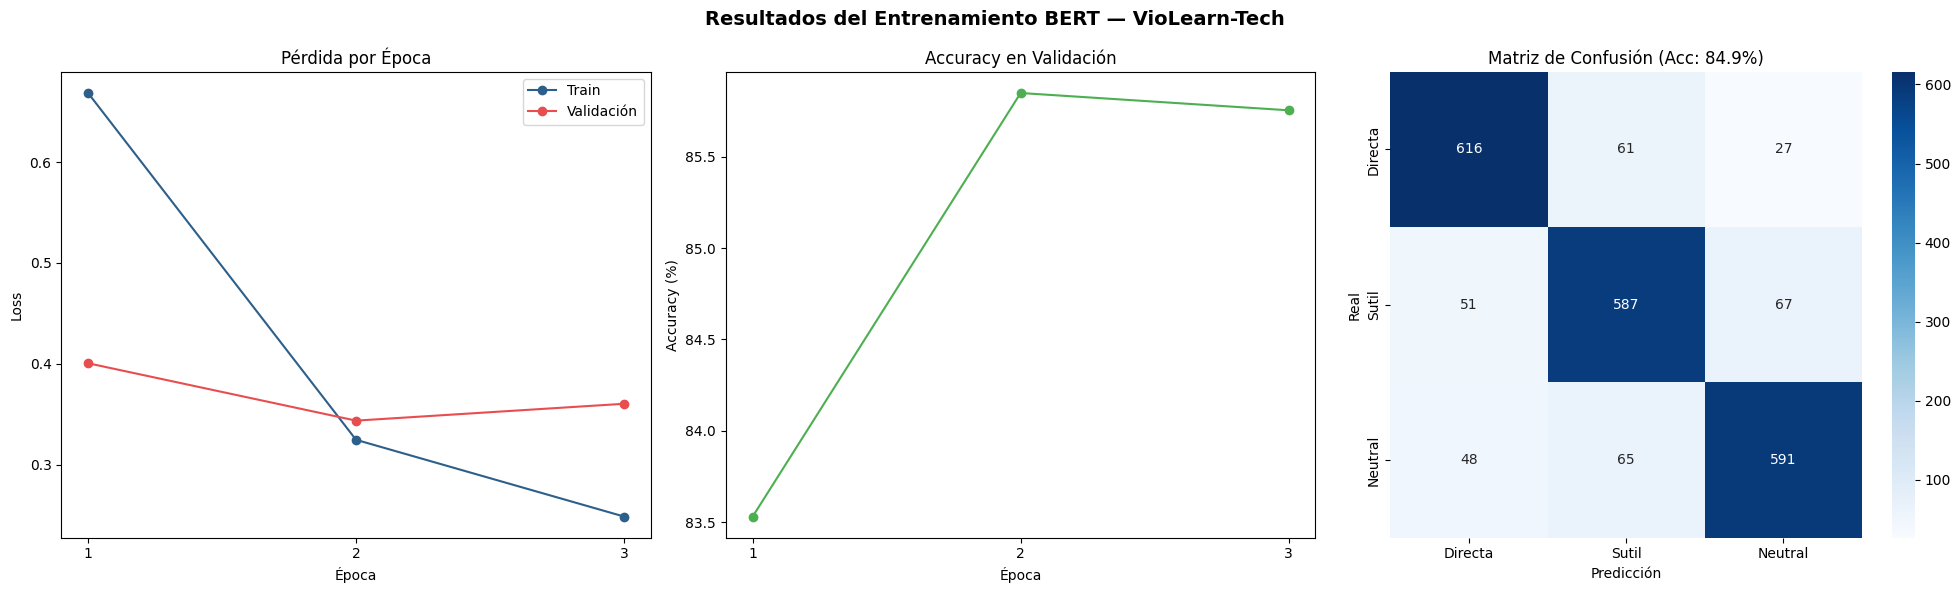

Figura guardada: 05_resultados_BERT.png


In [21]:
# ══════════════════════════════════════════════════════════
# GRÁFICAS DE RESULTADOS DEL ENTRENAMIENTO
# 3 paneles: curvas de pérdida, accuracy por época, matriz de confusión
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Resultados del Entrenamiento BERT — VioLearn-Tech",
             fontsize=14, fontweight="bold")

epocas = range(1, EPOCHS + 1)

# ── Panel 1: Curvas de pérdida ───────────────────────────
ax = axes[0]
ax.plot(epocas, historial["loss_train"], 'o-', label="Train", color="#2C5F8A")
ax.plot(epocas, historial["loss_val"],   'o-', label="Validación", color="#E84E4F")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.set_title("Pérdida por Época")
ax.legend()
ax.set_xticks(list(epocas))

# ── Panel 2: Accuracy por época ──────────────────────────
ax = axes[1]
ax.plot(epocas, [a*100 for a in historial["acc_val"]], 'o-', color="#4CAF50")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy en Validación")
ax.set_xticks(list(epocas))

# ── Panel 3: Matriz de confusión ─────────────────────────
ax = axes[2]
cm = confusion_matrix(labels_test, preds_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Directa", "Sutil", "Neutral"],
            yticklabels=["Directa", "Sutil", "Neutral"],
            ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de Confusión (Acc: {acc_final*100:.1f}%)")

plt.tight_layout()
plt.savefig("05_resultados_BERT.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 05_resultados_BERT.png")

---
## PASO 12 — Clasificar TODO el corpus con BERT

Hasta ahora BERT solo evaluó los datos de prueba (15%).  
Ahora aplicamos el modelo entrenado a **todos** los 184,572 textos  
del corpus completo.

In [22]:
# ══════════════════════════════════════════════════════════
# CLASIFICAR EL CORPUS COMPLETO CON BERT
# ══════════════════════════════════════════════════════════

print("Cargando corpus completo desde Drive...")

# Copiar el dataset completo clasificado por reglas
RUTA_COMPLETO = RUTA_DRIVE + 'reddit_data_clasificado_reglas.csv'
shutil.copy(RUTA_COMPLETO, 'reddit_data_clasificado_reglas.csv')

df_completo = pd.read_csv('reddit_data_clasificado_reglas.csv')
df_completo['texto'] = df_completo['texto'].fillna('').astype(str)

print(f"Corpus completo: {len(df_completo):,} textos")
print("Clasificando con BERT...")

def predecir_lote(textos_lote, model, tokenizer, device, max_len=128):
    """
    Predice categorías para un lote de textos.

    Parámetros:
        textos_lote (list): lista de textos a clasificar
        model: modelo BERT entrenado
        tokenizer: tokenizador de BERT
        device: GPU o CPU
        max_len: longitud máxima de tokens
    Retorna:
        list: predicciones numéricas (0, 1, 2) para cada texto
    """
    # Tokenizar el lote
    enc = tokenizer(
        textos_lote,
        max_length=max_len,
        padding=True,         # Padding dinámico (solo hasta el texto más largo del lote)
        truncation=True,
        return_tensors='pt'
    )
    enc = {k: v.to(device) for k, v in enc.items()}  # Mover a GPU

    model.eval()  # Modo evaluación
    with torch.no_grad():  # Sin gradientes
        outputs = model(**enc)  # ** desempaqueta el diccionario como argumentos

    return torch.argmax(outputs.logits, dim=1).cpu().tolist()  # Predicciones

# ── Procesar en lotes de 64 ──────────────────────────────
# Más grande = más rápido, pero más memoria GPU
LOTE = 64
todas_predicciones = []

for i in range(0, len(df_completo), LOTE):
    lote = df_completo['texto'].iloc[i:i+LOTE].tolist()  # Tomar un lote de 64 textos
    preds = predecir_lote(lote, model, tokenizer, device)  # Clasificar
    todas_predicciones.extend(preds)  # Agregar a la lista total

    # Mostrar progreso cada 5,000 textos
    if i % 5000 == 0:
        pct = i / len(df_completo) * 100
        print(f"  {i:>7,} / {len(df_completo):,}  ({pct:.1f}%)")

# Convertir números (0, 1, 2) a nombres de categoría
df_completo['categoria_BERT'] = [LABEL_MAP_INVERSO[p] for p in todas_predicciones]

# Mostrar distribución final
print(f"\nClasificación completada!")
print(f"\nDistribución final (BERT):")
for cat, n in df_completo['categoria_BERT'].value_counts().items():
    print(f"  {cat:<22}: {n:>7,} ({n/len(df_completo)*100:.1f}%)")

Cargando corpus completo desde Drive...
Corpus completo: 184,572 textos
Clasificando con BERT...
        0 / 184,572  (0.0%)
   40,000 / 184,572  (21.7%)
   80,000 / 184,572  (43.3%)
  120,000 / 184,572  (65.0%)
  160,000 / 184,572  (86.7%)

Clasificación completada!

Distribución final (BERT):
  NEUTRAL               : 141,566 (76.7%)
  VIOLENCIA_SUTIL       :  21,781 (11.8%)
  VIOLENCIA_DIRECTA     :  21,225 (11.5%)


---
## PASO 13 — Guardar resultados en Drive

In [25]:
# ══════════════════════════════════════════════════════════
# GUARDAR TODO EN GOOGLE DRIVE
# Colab puede desconectarse en cualquier momento, así que
# guardamos todo en Drive para no perder el trabajo
# ══════════════════════════════════════════════════════════

import os
import zipfile

# Guardar el CSV clasificado por BERT
df_completo.to_csv('reddit_data_clasificado_BERT.csv', index=False)
print("CSV guardado: reddit_data_clasificado_BERT.csv")

# Copiar archivos a Google Drive
shutil.copy('reddit_data_clasificado_BERT.csv',
            RUTA_DRIVE + 'reddit_data_clasificado_BERT.csv')
shutil.copy('05_resultados_BERT.png',
            RUTA_DRIVE + '05_resultados_BERT.png')

# Comprimir el modelo BERT para descargar
# El modelo son varios archivos (~440MB), comprimirlos facilita la descarga
import zipfile
with zipfile.ZipFile('bert_violencia_tech.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for archivo in os.listdir('bert_violencia_tech'):
        z.write(f'bert_violencia_tech/{archivo}')

shutil.copy('bert_violencia_tech.zip',
            RUTA_DRIVE + 'bert_violencia_tech.zip')

print("\nTodo guardado en Google Drive.")

# ── Resumen final ────────────────────────────────────────
print("\n" + "=" * 60)
print("RESUMEN — NOTEBOOK 05: BERT")
print("=" * 60)
print(f"  Modelo             : {MODEL_NAME}")
print(f"  Parámetros         : {params_millones:.0f}M")
print(f"  Épocas             : {EPOCHS}")
print(f"  Learning rate      : {LR}")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Max tokens         : {MAX_LEN}")
print(f"  Accuracy final     : {acc_final*100:.2f}%")
print(f"  Tiempo total       : {tiempo_total//60}min {tiempo_total%60}s")
print(f"  Corpus clasificado : {len(df_completo):,} textos")
print(f"\nArchivos en Drive:")
print(f"  reddit_data_clasificado_BERT.csv")
print(f"  05_resultados_BERT.png")
print(f"  bert_violencia_tech.zip")
print("=" * 60)
print("\n→ Siguiente paso: Notebook 06_Analisis_Temporal")
print("  Copia reddit_data_clasificado_BERT.csv a tu carpeta local")
print("  y ponlo en data/processed/")

CSV guardado: reddit_data_clasificado_BERT.csv

Todo guardado en Google Drive.

RESUMEN — NOTEBOOK 05: BERT
  Modelo             : bert-base-uncased
  Parámetros         : 109M
  Épocas             : 3
  Learning rate      : 2e-05
  Batch size         : 32
  Max tokens         : 128
  Accuracy final     : 84.90%
  Tiempo total       : 10min 54s
  Corpus clasificado : 184,572 textos

Archivos en Drive:
  reddit_data_clasificado_BERT.csv
  05_resultados_BERT.png
  bert_violencia_tech.zip

→ Siguiente paso: Notebook 06_Analisis_Temporal
  Copia reddit_data_clasificado_BERT.csv a tu carpeta local
  y ponlo en data/processed/
